In [ ]:
import gdown

file_id = "13QJM13VbLZ_X562XXk0M9GAe4iqe5YW0"
output = "unified_dataset.zip"

gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)


Downloading...
From (original): https://drive.google.com/uc?id=13QJM13VbLZ_X562XXk0M9GAe4iqe5YW0
From (redirected): https://drive.google.com/uc?id=13QJM13VbLZ_X562XXk0M9GAe4iqe5YW0&confirm=t&uuid=7153e341-20f7-4737-863a-d82d972816ab
To: /content/unified_dataset.zip
100%|██████████| 8.39G/8.39G [03:43<00:00, 37.5MB/s]


'unified_dataset.zip'

In [ ]:
import zipfile
import os

zip_path = "/content/unified_dataset.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall("/content")

os.listdir("/content")


['.config', 'unified_dataset.zip', 'unified_dataset', 'sample_data']

In [ ]:
from detectron2.data.datasets import register_coco_instances
from detectron2.data import MetadataCatalog, DatasetCatalog


DATASET_ROOT   = "/content/unified_dataset"      # folder that contains images + annotations
TRAIN_JSON     = f"{DATASET_ROOT}/annotations/train.json"
VAL_JSON       = f"{DATASET_ROOT}/annotations/val.json"
TRAIN_IMAGES   = f"{DATASET_ROOT}/images/train"
VAL_IMAGES     = f"{DATASET_ROOT}/images/val"

register_coco_instances("day_fire_train", {}, TRAIN_JSON, TRAIN_IMAGES)
register_coco_instances("day_fire_val",   {}, VAL_JSON,   VAL_IMAGES)

train_meta = MetadataCatalog.get("day_fire_train")
print("thing_classes from JSON:", train_meta.thing_classes)

print("Train images:", len(DatasetCatalog.get("day_fire_train")))
print("Val   images:", len(DatasetCatalog.get("day_fire_val")))


ModuleNotFoundError: No module named 'detectron2'

In [ ]:
from detectron2.data import DatasetCatalog

d = DatasetCatalog.get("day_fire_train")
print("num train samples:", len(d))
print(d[0].keys())
print("meta classes:", MetadataCatalog.get("day_fire_train").thing_classes)


Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.



num train samples: 18824
dict_keys(['file_name', 'height', 'width', 'image_id', 'annotations'])
meta classes: ['fire', 'smoke']


## **Training**

In [ ]:
import os
from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.evaluation import COCOEvaluator
from detectron2.data import build_detection_test_loader
from detectron2.evaluation import inference_on_dataset

cfg = get_cfg()
cfg.merge_from_file(
    model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")
)

# Datasets
cfg.DATASETS.TRAIN = ("day_fire_train",)
cfg.DATASETS.TEST  = ("day_fire_val",)

cfg.DATALOADER.NUM_WORKERS = 2

cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 5e-4

cfg.SOLVER.MAX_ITER = 9000


cfg.SOLVER.STEPS = (6000, 8000)
cfg.SOLVER.GAMMA = 0.1

cfg.SOLVER.WARMUP_ITERS = 1000
cfg.SOLVER.CHECKPOINT_PERIOD = 3000


# ROI heads for 2 classes (fire + smoke)
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 256  # per-image RoIs
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 2

# Pretrained COCO weights
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
    "COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"
)

# Output directory
cfg.OUTPUT_DIR = "/content/daytime_frcnn_outputs"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
print("Training output dir:", cfg.OUTPUT_DIR)

# Trainer
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

# Evaluation on validation set
evaluator  = COCOEvaluator("day_fire_val", cfg, False, output_dir=cfg.OUTPUT_DIR)
val_loader = build_detection_test_loader(cfg, "day_fire_val")

print("\nRunning evaluation on validation set...")
metrics = inference_on_dataset(trainer.model, val_loader, evaluator)
print("Validation metrics:", metrics)


Training output dir: /content/daytime_frcnn_outputs
[12/25 07:44:30 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_

roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}


[12/25 07:44:31 d2.engine.train_loop]: Starting training from iteration 0
[12/25 07:44:41 d2.utils.events]:  eta: 1:18:49  iter: 19  total_loss: 1.309  loss_cls: 1.054  loss_box_reg: 0.1219  loss_rpn_cls: 0.1267  loss_rpn_loc: 0.03399    time: 0.5133  last_time: 0.5634  data_time: 0.0216  last_data_time: 0.0122   lr: 9.9905e-06  max_mem: 4254M
[12/25 07:44:52 d2.utils.events]:  eta: 1:18:18  iter: 39  total_loss: 1.114  loss_cls: 0.8475  loss_box_reg: 0.09355  loss_rpn_cls: 0.09506  loss_rpn_loc: 0.01425    time: 0.5102  last_time: 0.5398  data_time: 0.0074  last_data_time: 0.0086   lr: 1.998e-05  max_mem: 4254M
[12/25 07:45:02 d2.utils.events]:  eta: 1:18:29  iter: 59  total_loss: 0.8274  loss_cls: 0.5479  loss_box_reg: 0.112  loss_rpn_cls: 0.1272  loss_rpn_loc: 0.02364    time: 0.5150  last_time: 0.4587  data_time: 0.0089  last_data_time: 0.0055   lr: 2.9971e-05  max_mem: 4254M
[12/25 07:45:13 d2.utils.events]:  eta: 1:18:38  iter: 79  total_loss: 0.6648  loss_cls: 0.3785  loss_box_r

KeyError: 'info'

## **Detectron2 + SAHI + SAM2**

In [ ]:
import torch, torchvision
print("Torch version:", torch.__version__)

!pip install -U 'git+https://github.com/facebookresearch/detectron2.git'
!pip install -q "sahi>=0.11.15"
!pip install -q "git+https://github.com/facebookresearch/segment-anything-2.git"

import os
import cv2
import numpy as np
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from detectron2 import model_zoo


cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 2
cfg.INPUT.MIN_SIZE_TEST = 800
cfg.INPUT.MAX_SIZE_TEST = 1333

OUTPUT_DIR = "/content/day_fire_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

WEIGHTS_PATH = os.path.join(OUTPUT_DIR, "Day_Model.pth")
cfg.MODEL.WEIGHTS = WEIGHTS_PATH
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.4
cfg.MODEL.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

predictor_d2 = DefaultPredictor(cfg)
print("Detectron2 predictor ready on", cfg.MODEL.DEVICE)

# ---------- SAHI ----------
from sahi.models.detectron2 import Detectron2DetectionModel
from sahi.predict import get_sliced_prediction

D2_CONFIG_PATH = "/content/day_frcnn_2cls.yaml"
with open(D2_CONFIG_PATH, "w") as f:
    f.write(cfg.dump())

SCORE_THRESH = 0.4
SAHI_SLICE_H = 512
SAHI_SLICE_W = 512
SAHI_OVERLAP = 0.2

d2_sahi_model = Detectron2DetectionModel(
    model_path=WEIGHTS_PATH,
    config_path=D2_CONFIG_PATH,
    confidence_threshold=SCORE_THRESH,
    device=str(cfg.MODEL.DEVICE),
)

print("SAHI Detectron2DetectionModel ready")

# ---------- SAM2 ----------
from sam2.build_sam import build_sam2_hf
from sam2.sam2_image_predictor import SAM2ImagePredictor

SAM_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
sam2_model = build_sam2_hf("facebook/sam2-hiera-large", device=SAM_DEVICE)
sam2_model.eval()
sam2_predictor = SAM2ImagePredictor(sam2_model)
print("SAM2 Large ready on", SAM_DEVICE)

# ---------- Temporal tracking params ----------
TEMPORAL_ALPHA = 0.6
TEMPORAL_MASK_THRESH = 0.5


Torch version: 2.9.0+cu126
  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-88k8ockq
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-88k8ockq
  Resolved https://github.com/facebookresearch/detectron2.git to commit fd27788985af0f4ca800bca563acdb700bb890e2
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
detectron2 0.6 requires iopath<0.1.10,>=0.1.7, but you have iopath 0.1.10 which is incompatible.
✅ Detectron2 predictor ready on cuda
/content/day_frcnn_2cls.yaml not available in Model Zoo!
✅ SAHI Detectron2DetectionModel ready


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


✅ SAM2 Large ready on cuda


## **Define Inference & Visualization Functions**

In [ ]:
def detect_fire_boxes_sahi(img_rgb):
    """
    SAHI + Detectron2 sliced prediction.
    Returns FIRE boxes and scores only (xyxy, float32),
    plus boxes/labels/scores for visualization.
    """
    result = get_sliced_prediction(
        image=img_rgb,
        detection_model=d2_sahi_model,
        slice_height=SAHI_SLICE_H,
        slice_width=SAHI_SLICE_W,
        overlap_height_ratio=SAHI_OVERLAP,
        overlap_width_ratio=SAHI_OVERLAP,
    )

    fire_boxes = []
    fire_scores = []
    vis_boxes = []
    vis_labels = []
    vis_scores = []

    for obj in result.object_prediction_list:
        bbox = obj.bbox
        x1, y1, x2, y2 = bbox.minx, bbox.miny, bbox.maxx, bbox.maxy
        score = float(obj.score.value)

        cat = getattr(obj, "category", None)
        cat_id = getattr(cat, "id", None) if cat is not None else None


        if cat_id == 0:
            label = "fire"
        elif cat_id == 1:
            label = "smoke"
        else:
            label = "fire"

        vis_boxes.append([x1, y1, x2, y2])
        vis_labels.append(label)
        vis_scores.append(score)

        # Only FIRE boxes go to SAM2
        if label == "fire":
            fire_boxes.append([x1, y1, x2, y2])
            fire_scores.append(score)

    if len(fire_boxes) == 0:
        fire_boxes = np.empty((0, 4), dtype=np.float32)
        fire_scores = np.empty((0,), dtype=np.float32)
    else:
        fire_boxes = np.array(fire_boxes, dtype=np.float32)
        fire_scores = np.array(fire_scores, dtype=np.float32)

    return fire_boxes, fire_scores, vis_boxes, vis_labels, vis_scores



def sam2_mask_from_boxes(img_rgb, boxes_xyxy):
    """
    Run SAM2 once per frame, segment each FIRE box, OR all masks together.
    boxes_xyxy: (N,4) in [x1,y1,x2,y2]
    """
    if len(boxes_xyxy) == 0:
        return np.zeros(img_rgb.shape[:2], dtype=bool)

    sam2_predictor.set_image(img_rgb)
    combined = np.zeros(img_rgb.shape[:2], dtype=bool)

    for box in boxes_xyxy:
        box = np.array(box, dtype=np.float32)
        with torch.inference_mode():
            masks, scores, logits = sam2_predictor.predict(
                box=box[None, :],
                multimask_output=False,
            )
        combined |= masks[0].astype(bool)

    return combined


def temporal_update_mask(inst_mask_bool, prev_mask_prob):
    """
    Exponential moving average over masks.

    inst_mask_bool : current frame SAM2 mask (bool)
    prev_mask_prob : previous frame probability map or None
    returns:
        temporal_mask (bool),
        mask_prob (float32) to be reused next frame
    """
    inst_float = inst_mask_bool.astype(np.float32)

    if prev_mask_prob is None:
        mask_prob = inst_float
    else:
        mask_prob = (
            TEMPORAL_ALPHA * inst_float
            + (1.0 - TEMPORAL_ALPHA) * prev_mask_prob
        )

    temporal_mask = mask_prob >= TEMPORAL_MASK_THRESH
    return temporal_mask, mask_prob


def draw_overlay(img_rgb, vis_boxes, vis_labels, vis_scores, fire_mask_bool):
    """
    Draw boxes (fire+smoke) and SAM2 fire segmentation (optionally temporally smoothed).
    Returns RGB image.
    """
    vis = img_rgb.copy()

    # draw boxes
    for (x1, y1, x2, y2), label, score in zip(vis_boxes, vis_labels, vis_scores):
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
        if label == "fire":
            color = (255, 255, 0)  # yellow in RGB
        else:
            color = (0, 255, 255)  # cyan for smoke

        cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)
        cv2.putText(
            vis,
            f"{label} {score:.2f}",
            (x1, max(0, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            1,
            cv2.LINE_AA,
        )

    # draw fire segmentation in red
    if fire_mask_bool is not None and fire_mask_bool.any():
        overlay = vis.astype(np.float32)
        overlay[fire_mask_bool] = 0.6 * overlay[fire_mask_bool] + 0.4 * np.array(
            [0, 0, 255], dtype=np.float32
        )
        vis = overlay.astype(np.uint8)

    return vis


### **Single Frame Pipeline**

In [ ]:
def process_frame_with_sahi_sam2_temporal(frame_bgr, prev_mask_prob=None):
    """
    Full pipeline for ONE frame:
      BGR frame → RGB
      SAHI detection (fire+smoke) → FIRE boxes
      SAM2 segmentation for fire boxes
      temporal smoothing over masks
      overlay boxes + mask
    """
    img_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

    # 1) SAHI detection
    fire_boxes, fire_scores, vis_boxes, vis_labels, vis_scores = \
        detect_fire_boxes_sahi(img_rgb)

    # 2) instantaneous SAM2 mask for fire
    inst_fire_mask = sam2_mask_from_boxes(img_rgb, fire_boxes)

    # 3) temporal tracking
    temporal_mask, mask_prob = temporal_update_mask(inst_fire_mask, prev_mask_prob)

    # 4) overlay
    vis_rgb = draw_overlay(img_rgb, vis_boxes, vis_labels, vis_scores, temporal_mask)
    vis_bgr = cv2.cvtColor(vis_rgb, cv2.COLOR_RGB2BGR)

    return vis_bgr, mask_prob


### **Run Inference on a Single Image**

In [ ]:
def run_on_image(image_path, save_path=None, show=True):
    frame_bgr = cv2.imread(image_path)
    assert frame_bgr is not None, f"Cannot read image: {image_path}"

    vis_bgr, _ = process_frame_with_sahi_sam2_temporal(
        frame_bgr, prev_mask_prob=None
    )

    if save_path is not None:
      out_dir = os.path.dirname(save_path)
      if out_dir != "":
          os.makedirs(out_dir, exist_ok=True)
      cv2.imwrite(save_path, vis_bgr)


    if show:
        import matplotlib.pyplot as plt
        vis_rgb = cv2.cvtColor(vis_bgr, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8, 6))
        plt.imshow(vis_rgb)
        plt.axis("off")
        plt.title(os.path.basename(image_path))
        plt.show()

    return vis_bgr


### **Run Full Inference on Video**

In [ ]:
def run_on_video(video_path, out_path, max_frames=None):
    cap = cv2.VideoCapture(video_path)
    assert cap.isOpened(), f"Cannot open video: {video_path}"

    out_dir = os.path.dirname(out_path)
    if out_dir != "":
        os.makedirs(out_dir, exist_ok=True)

    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(out_path, fourcc, fps, (w, h))

    frame_idx = 0
    prev_mask_prob = None

    while True:
        ret, frame_bgr = cap.read()
        if not ret:
            break

        vis_bgr, prev_mask_prob = process_frame_with_sahi_sam2_temporal(
            frame_bgr, prev_mask_prob
        )
        writer.write(vis_bgr)

        frame_idx += 1
        if max_frames is not None and frame_idx >= max_frames:
            break
        if frame_idx % 50 == 0:
            print("Processed frame", frame_idx)

    cap.release()
    writer.release()
    print("Saved:", out_path)


### Test Pipeline on a Single Image

Performing prediction on 15 slices.


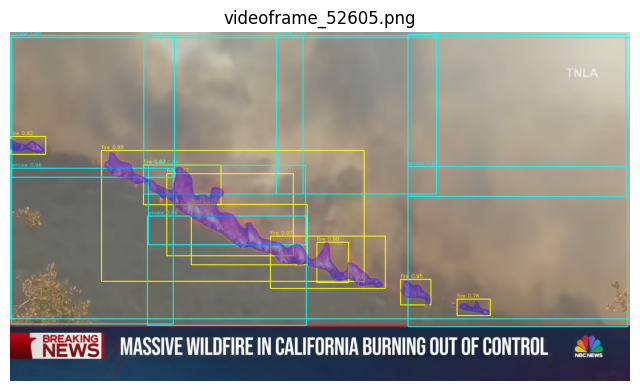

Saved image to: /content/results/test_fire_sahi_sam2_temp.jpg


In [ ]:
img_path  = "/content/videoframe_52605.png"          # <- change
save_path = "/content/results/test_fire_sahi_sam2_temp.jpg"

_ = run_on_image(img_path, save_path=save_path, show=True)
print("Saved image to:", save_path)


### Test Pipeline on a Video

In [ ]:
video_in  = "/content/sideways_fire.mp4"         # <- change
video_out = "/content/results/output_fire_sahi_sam2_temp.mp4"

run_on_video(video_in, video_out, max_frames=None)


Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing predictio